In [25]:
import sys
sys.path.append('../..')

from src import utils
import src.channelCoding as cc
from pymongo import MongoClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl
import matplotlib.patheffects as pe
import hmac


# MongoDB connection


clients = MongoClient('mongodb://localhost:27017/')
dbs = []
for db in clients.list_database_names():
    if db.startswith('r0_r1_SC_alpha'):
        dbs.append(clients[db]['destination, phase_1'])

In [26]:
dbs

[Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'r0_r1_SC_alpha_0_15_R=0_5'), 'destination, phase_1'),
 Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'r0_r1_SC_alpha_0_1_R=0_5'), 'destination, phase_1'),
 Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'r0_r1_SC_alpha_0_25_R=0_5'), 'destination, phase_1'),
 Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'r0_r1_SC_alpha_0_2_R=0_5'), 'destination, phase_1'),
 Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'r0_r1_SC_alpha_0_35_R=0_5'), 'destination, phase_1'),
 Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'r0_r1_SC_alpha_0_3_R=0_5'), 'destination, phase_1'),
 Collec

In [27]:
pd.DataFrame(list(dbs[0].find({}))).head()

,_id,BER_tag,BER_msg,r0,r1,SNR,sigma_n2,config
0,6894fae435183f9455c80198,0.415776,0.112870,"[0.0035002999506680574, 1.608149210198656e-05,...","[0.00011501964092315682, 0.0017967992979043698...",3.479410,1.135969e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
1,6894fae835183f9455c8019a,0.409882,0.118284,"[0.020515778419189758, 6.063725933310875e-05, ...","[0.007999962239559923, 0.0004983216484357129, ...",3.353220,1.135997e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
2,6894faf835183f9455c8019e,0.412623,0.115611,"[0.002890010292392732, 0.0004200082488713003, ...","[0.000321349721079031, 0.001360360918212201, 0...",3.516576,1.122915e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
3,6894fafc35183f9455c801a0,0.407758,0.118764,"[0.0016537297378702305, 0.00024151345022659155...","[0.0006575901646520354, 0.0015212043221508344,...",3.445645,1.122834e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
4,6894fb0c35183f9455c801a4,0.408512,0.116982,"[0.000910318762541555, 0.0004458230320787859, ...","[6.460786267658703e-05, 0.0010863399173612583,...",3.506718,1.127338e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."


/tmp/ipykernel_1887910/656628211.py:86: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  msg_cmap = mpl.cm.get_cmap(msg_cmap_name)
/tmp/ipykernel_1887910/656628211.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tag_cmap = mpl.cm.get_cmap(tag_cmap_name)


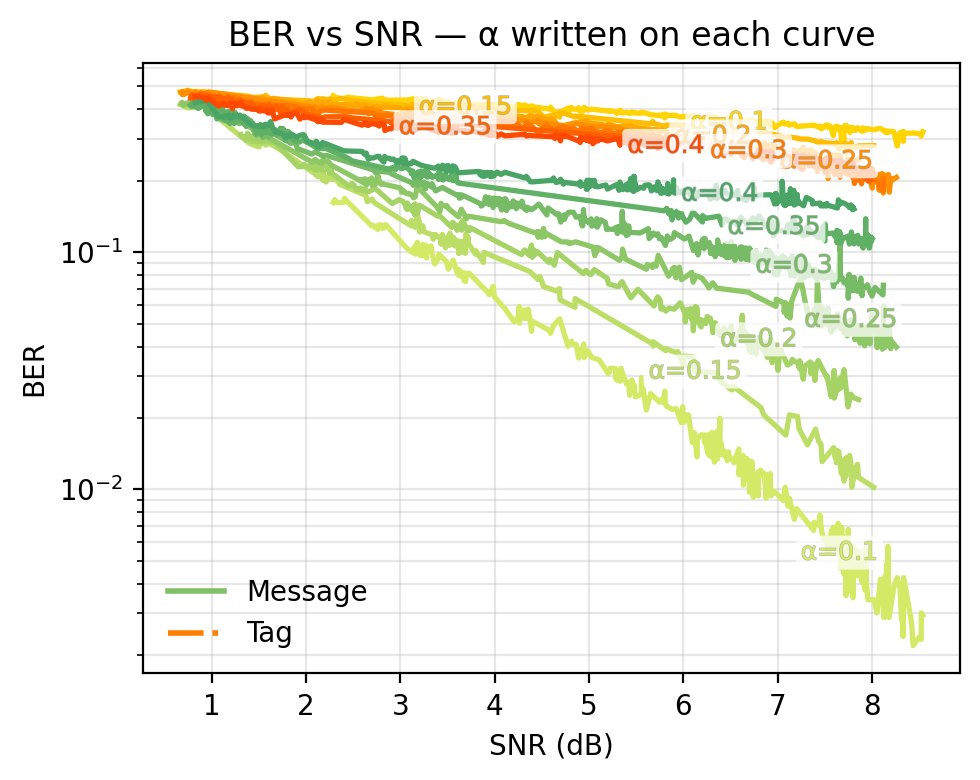

In [39]:


# --- alpha from your docs ---------------------------------------------------
def infer_alpha(coll):
    return float(coll.find_one({})["config"]["ALPHA"])

def infer_msg_tag(coll):
    temp = coll.find_one({})["config"]
    len_MAC_encoded = int(np.ceil(256/temp["MAC_REP"]/temp["MAC_LDPC"]))
    len_msg = int(np.ceil((len_MAC_encoded - 512) * temp['MSG_CODE_RATE']))
    msg_str = temp['PAYLOAD'][:len_msg//8]
    msg_encoded = cc.encode_LDPC(utils.string_to_bits(msg_str), Codeword_length=len_MAC_encoded)
    tag = hmac.new(key=temp['MAC_KEY'].encode('utf-8'),
                   msg= msg_str.encode('utf-8'),
                     digestmod=temp['MAC_SHA']).hexdigest()
    tag_bits = utils.hex_to_bits(tag)
    tag_encoded = cc.encode_LDPC(tag_bits, Codeword_length=int(np.ceil(256/temp["MAC_LDPC"])))
    tag_encoded = np.repeat(tag_encoded, int(np.ceil(1//temp["MAC_REP"])))
    return msg_encoded, tag_encoded
    
    



# --- helpers ----------------------------------------------------------------
def df_from_collection(coll):
    cur = coll.find({}, {"BER_tag": 1, "BER_msg": 1, "SNR": 1, "_id": 0})
    df = pd.DataFrame(list(cur))
    if df.empty:
        return df
    for c in ["BER_tag", "BER_msg", "SNR"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.dropna(subset=["BER_tag", "BER_msg", "SNR"])
    df = (df.groupby("SNR", as_index=False)
            .agg(BER_tag=("BER_tag","mean"), BER_msg=("BER_msg","mean"))
            .sort_values("SNR"))
    df["alpha"] = infer_alpha(coll)
    return df


def _text_on_curve(ax, x, y, text, color, frac=0.78,
                   bbox_fc="white", bbox_alpha=0.75):
    """
    Place 'text' ON the curve around the given fractional position (0..1),
    rotated to match the local slope. Adds a rounded, semi-opaque background.
    """
    if len(x) < 2:
        return
    xi = np.asarray(x); yi = np.asarray(y)
    idx = int(np.clip(frac * (len(xi)-1), 1, len(xi)-2))

    # rotation angle using log10(y) because the y-axis is logarithmic
    dy = np.log10(yi[idx+1]) - np.log10(yi[idx-1])
    dx = xi[idx+1] - xi[idx-1]
    angle = 0#np.degrees(np.arctan2(dy, dx))

    ax.text(
        xi[idx], yi[idx], text,
        color=color, fontsize=9, ha="center", va="center",
        rotation=angle, rotation_mode="anchor",
        zorder=5,
        bbox=dict(facecolor=bbox_fc, alpha=bbox_alpha,
                  edgecolor="none", boxstyle="round,pad=0.2"),
        # small halo as extra insurance against busy backgrounds
        path_effects=[pe.withStroke(linewidth=0.5, foreground="black", alpha=0.25)]
    )


def plot_ber_vs_snr_by_alpha(dbs, save_to=None,
                             msg_cmap_name='summer', tag_cmap_name="autumn"):
    series = []
    for coll in dbs:
        g = df_from_collection(coll)
        if not g.empty:
            series.append((float(g["alpha"].iloc[0]), g))
    if not series:
        print("No data to plot.")
        return

    # sort so darker (low α) are drawn first, brighter on top
    series.sort(key=lambda x: x[0])
    alphas = [a for a, _ in series]
    a_min, a_max = min(alphas), max(alphas)
    if a_max == a_min:
        a_max = a_min + 1e-12

    norm = mpl.colors.Normalize(vmin=.05*a_min, vmax=1.4*a_max)
    msg_cmap = mpl.cm.get_cmap(msg_cmap_name)
    tag_cmap = mpl.cm.get_cmap(tag_cmap_name)

    fig, ax = plt.subplots(figsize=(5, 4), dpi= 200)


    for a, g in series:
        # invert intensity so higher α => brighter
        shade = 1.0 - norm(a)
        msg_color = msg_cmap(shade)
        tag_color = tag_cmap(shade)

        ax.plot(g["SNR"], g["BER_msg"], linestyle="-",
                linewidth=1.9, markersize=4, color=msg_color)
        ax.plot(g["SNR"], g["BER_tag"], linestyle="-",
                linewidth=1.9, markersize=4, color=tag_color)

        # write α on each line (slightly different positions to reduce overlap)
        _text_on_curve(ax, g["SNR"], g["BER_msg"], f"α={a:g}", msg_color, frac=0.78)
        _text_on_curve(ax, g["SNR"], g["BER_tag"], f"α={a:g}", tag_color, frac=0.62)

    # styling
    ax.set_yscale("log")
    ax.set_xlabel("SNR (dB)")
    ax.set_ylabel("BER")
    ax.set_title("BER vs SNR — α written on each curve")
    ax.grid(True, which="both", alpha=0.3)

    # tiny legend just for type
    from matplotlib.lines import Line2D
    ax.legend(handles=[
        Line2D([0],[0], color=msg_cmap(0.5), lw=2, linestyle="-", label="Message"),
        Line2D([0],[0], color=tag_cmap(0.5), lw=2, linestyle="-.", label="Tag"),
    ], loc="lower left", frameon=False)

    fig.tight_layout()
    if save_to:
        fig.savefig(save_to, dpi=220, bbox_inches="tight")
    # plt.xlim(left=0.5, right=4)
    # plt.ylim(bottom=5*1e-2, top=1)
    plt.show()

# Usage:
plot_ber_vs_snr_by_alpha(dbs, save_to="ber_vs_snr_alpha_on_line.png")



In [29]:
dfs = {}
for db in dbs:
    dfs[str(infer_alpha(db))] = pd.DataFrame(list(db.find({})))


In [30]:
dfs['0.15'].head()

,_id,BER_tag,BER_msg,r0,r1,SNR,sigma_n2,config
0,6894fae435183f9455c80198,0.415776,0.112870,"[0.0035002999506680574, 1.608149210198656e-05,...","[0.00011501964092315682, 0.0017967992979043698...",3.479410,1.135969e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
1,6894fae835183f9455c8019a,0.409882,0.118284,"[0.020515778419189758, 6.063725933310875e-05, ...","[0.007999962239559923, 0.0004983216484357129, ...",3.353220,1.135997e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
2,6894faf835183f9455c8019e,0.412623,0.115611,"[0.002890010292392732, 0.0004200082488713003, ...","[0.000321349721079031, 0.001360360918212201, 0...",3.516576,1.122915e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
3,6894fafc35183f9455c801a0,0.407758,0.118764,"[0.0016537297378702305, 0.00024151345022659155...","[0.0006575901646520354, 0.0015212043221508344,...",3.445645,1.122834e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."
4,6894fb0c35183f9455c801a4,0.408512,0.116982,"[0.000910318762541555, 0.0004458230320787859, ...","[6.460786267658703e-05, 0.0010863399173612583,...",3.506718,1.127338e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col..."


In [40]:
db.find_one({})['config']
msg_bits, tag_bits = infer_msg_tag(db)


array([0., 0., 0., ..., 0., 0., 0.])

In [32]:
from scipy.special import erfc


# Define Q-function
def qfunc(x):
    return 0.5 * erfc(x / np.sqrt(2))
# Error rate function
def error_rate(l, R, p):

    # Avoid log(0) issues by adding a very small number when needed.
    p = np.where(p == 0, 1e-19, p)
    one_minus_p = 1 - p
    C = 1 + p * np.log2(p) + one_minus_p * np.log2(one_minus_p)
    denom = np.log2(one_minus_p / p)
    term = np.sqrt(l / (p * one_minus_p)) * ((C - R) / denom)
    return qfunc(term)

In [ ]:
import numpy as np

def decode_superposed_fsk(
    E0, E1, snr, sigma_n2, alpha, snr_is_db=True, return_confidence=True
):
    """
    E0, E1: 1D arrays (or lists) of per-symbol energies in f0 and f1 bins
    snr: scalar SNR for these symbols (linear or dB)
    sigma_n2: scalar noise variance per bin
    alpha: fraction of total symbol power allocated to the WEAK layer (0..1)
    snr_is_db: if True, 'snr' is in dB and will be converted to linear
    return_confidence: if True, also return a per-symbol confidence score

    Returns:
      msg_bits: np.ndarray of 0/1 (strong layer: 0=>f0, 1=>f1)
      tag_bits: np.ndarray of 0/1 (weak  layer: 0=>f0, 1=>f1)
      confidences (optional): np.ndarray in [0,1], larger => more confident
    """
    E0 = np.asarray(E0, dtype=float)
    E1 = np.asarray(E1, dtype=float)
    assert E0.shape == E1.shape

    # SNR (linear) and power model
    snr_lin = 10**(snr/10.0) if snr_is_db else float(snr)
    P_tot   = snr_lin * sigma_n2              # total signal power per symbol
    P_str   = (1.0 - alpha) * P_tot           # strong layer power
    P_weak  = alpha * P_tot                   # weak  layer power
    N       = sigma_n2                        # mean noise energy in an empty bin

    # Expected mean energies for each hypothesis (E0_hat, E1_hat)
    # H00: strong f0 + weak f0  => f0: P_tot + N,     f1: N
    # H01: strong f0 + weak f1  => f0: P_str + N,     f1: P_weak + N
    # H10: strong f1 + weak f0  => f0: P_weak + N,    f1: P_str + N
    # H11: strong f1 + weak f1  => f0: N,             f1: P_tot + N
    means = np.array([
        [P_tot + N,     N        ],  # H00
        [P_str + N,     P_weak + N],  # H01
        [P_weak + N,    P_str + N],  # H10
        [N,             P_tot + N],  # H11
    ])  # shape (4, 2)

    # For speed, compute squared errors to each hypothesis, vectorized
    # errs[h, i] = (E0[i]-means[h,0])^2 + (E1[i]-means[h,1])^2
    E = np.stack([E0, E1], axis=0)            # (2, n)
    diffs = E[None, :, :] - means[:, :, None] # (4, 2, n)
    errs  = np.sum(diffs**2, axis=1)          # (4, n)

    # Best hypothesis per symbol
    idx = np.argmin(errs, axis=0)             # (n,)
    # Map hypothesis index -> (msg_bit, tag_bit)
    # H00 -> (0,0), H01 -> (0,1), H10 -> (1,0), H11 -> (1,1)
    map_bits = np.array([[0,0],[0,1],[1,0],[1,1]])
    decoded = map_bits[idx]
    msg_bits = decoded[:,0]
    tag_bits = decoded[:,1]

    if not return_confidence:
        return msg_bits, tag_bits

    # Simple confidence: margin between best and second-best hypothesis
    sorted_errs = np.sort(errs, axis=0)       # (4, n)
    margin = sorted_errs[1] - sorted_errs[0]  # (n,)
    # Normalize margin to [0,1] for convenience (robust min-max)
    if margin.size > 0:
        lo, hi = np.percentile(margin, [10, 90])
        denom = max(hi - lo, 1e-12)
        conf = np.clip((margin - lo) / denom, 0.0, 1.0)
    else:
        conf = margin
    return msg_bits, tag_bits, conf


# ---- Example usage with one row from your DataFrame ----
# Suppose a row has: r0 (list of energies in f0), r1 (list in f1),
# SNR (likely dB), sigma_n2, and you know alpha.
row = dfs['0.15'].iloc[170]
msg, tag, conf = decode_superposed_fsk(row['r0'], row['r1'],
                                       snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                       alpha=0.15, snr_is_db=True)
row['SNR'], row['BER_msg'],np.sum(msg!=msg_bits)/len(msg_bits), row['BER_tag'],np.sum(tag!=tag_bits)/len(msg_bits)




(7.703593123864828,
 0.010827850877192983,
 0.010827850877192983,
 0.28803453947368424,
 0.4887609649122807)

In [70]:
import numpy as np

# ---- utilities ---------------------------------------------------------------
def _to_linear_snr(snr, snr_is_db):
    return 10**(snr/10.0) if snr_is_db else float(snr)

def _gauss_ll(x, P, sigma2):
    """
    Log-likelihood for energy x given signal power P and noise variance sigma2,
    using a Gaussian approx to the noncentral-chi^2 energy.
      mean = P + sigma2
      var  = sigma2**2 + 2*P*sigma2
    Returns log p(x | P, sigma2) up to an additive constant independent of P.
    """
    mu = P + sigma2
    var = sigma2**2 + 2.0*P*sigma2
    var = np.maximum(var, 1e-18)
    return -0.5*((x - mu)**2/var + np.log(var))

def _logsumexp(a, axis=0):
    m = np.max(a, axis=axis, keepdims=True)
    return (m + np.log(np.sum(np.exp(a - m), axis=axis, keepdims=True))).squeeze(axis)

# ---- expected powers for the four hypotheses --------------------------------
# H00: strong→f0, weak→f0
# H01: strong→f0, weak→f1
# H10: strong→f1, weak→f0
# H11: strong→f1, weak→f1
def _hypothesis_powers(P_str, P_weak):
    return np.array([
        [P_str + P_weak, 0.0          ],  # H00
        [P_str,          P_weak       ],  # H01
        [P_weak,         P_str        ],  # H10
        [0.0,            P_str + P_weak],  # H11
    ], dtype=float)  # shape (4, 2)

_map_bits = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=int)  # H -> (msg, tag)

# ---- Joint ML decoder --------------------------------------------------------
def decode_superposed_fsk_ml(E0, E1, snr, sigma_n2, alpha, snr_is_db=True, return_confidence=True):
    """
    Joint maximum-likelihood over the 4 hypotheses using variance-weighted likelihoods.
    """
    E0 = np.asarray(E0, float); E1 = np.asarray(E1, float)
    assert E0.shape == E1.shape
    snr_lin = _to_linear_snr(snr, snr_is_db)
    P_tot   = snr_lin * sigma_n2
    P_str   = (1.0 - alpha) * P_tot
    P_weak  = alpha * P_tot

    H = _hypothesis_powers(P_str, P_weak)  # (4,2)
    # log-likelihood for each hypothesis and symbol
    ll0 = np.stack([_gauss_ll(E0, H[h,0], sigma_n2) for h in range(4)])  # (4,n)
    ll1 = np.stack([_gauss_ll(E1, H[h,1], sigma_n2) for h in range(4)])  # (4,n)
    LL  = ll0 + ll1  # (4,n)

    idx = np.argmax(LL, axis=0)  # best hypothesis per symbol
    bits = _map_bits[idx]
    msg, tag = bits[:,0], bits[:,1]

    if not return_confidence:
        return msg, tag

    # confidence = margin between best and second-best log-likelihood
    sortedLL = np.sort(LL, axis=0)
    margin = sortedLL[-1] - sortedLL[-2]
    # normalize to [0,1] for convenience
    lo, hi = np.percentile(margin, [5,95]) if margin.size else (0,1)
    conf = np.clip((margin - lo)/max(hi-lo,1e-12), 0.0, 1.0)
    return msg, tag, conf

# ---- Soft SIC decoder --------------------------------------------------------
def decode_superposed_fsk_sic(E0, E1, snr, sigma_n2, alpha, snr_is_db=True):
    """
    Decode strong (msg) by marginalizing over weak (equal priors),
    then decode weak (tag) conditioned on the msg decision.
    Optionally subtract strong POWER before weak decision (power-domain SIC).
    """
    E0 = np.asarray(E0, float); E1 = np.asarray(E1, float)
    snr_lin = _to_linear_snr(snr, snr_is_db)
    P_tot   = snr_lin * sigma_n2
    P_str   = (1.0 - alpha) * P_tot
    P_weak  = alpha * P_tot

    H = _hypothesis_powers(P_str, P_weak)  # (4,2)
    ll0 = np.stack([_gauss_ll(E0, H[h,0], sigma_n2) for h in range(4)])  # (4,n)
    ll1 = np.stack([_gauss_ll(E1, H[h,1], sigma_n2) for h in range(4)])  # (4,n)
    LL  = ll0 + ll1  # (4,n)

    # Marginalize over weak bit for msg decision:
    # msg=0 -> hypotheses H00,H01; msg=1 -> H10,H11
    LL_msg0 = _logsumexp(LL[[0,1], :], axis=0) - np.log(2.0)
    LL_msg1 = _logsumexp(LL[[2,3], :], axis=0) - np.log(2.0)
    msg = (LL_msg1 > LL_msg0).astype(int)

    # Optional power subtraction (power-domain SIC)
    E0_res = E0.copy()
    E1_res = E1.copy()
    # subtract expected strong POWER from the decided bin (clip at 0)
    E0_res = np.where(msg==0, np.clip(E0_res - P_str, 0.0, None), E0_res)
    E1_res = np.where(msg==1, np.clip(E1_res - P_str, 0.0, None), E1_res)

    # Now decode weak given msg:
    # if msg=0: compare H00 vs H01; if msg=1: compare H10 vs H11
    # We re-evaluate LL on residual energies using ONLY weak power.
    Hw = _hypothesis_powers(0.0, P_weak)
    ll0w = np.stack([_gauss_ll(E0_res, Hw[h,0], sigma_n2) for h in range(4)])
    ll1w = np.stack([_gauss_ll(E1_res, Hw[h,1], sigma_n2) for h in range(4)])
    LLw  = ll0w + ll1w

    tag0 = (LLw[1] > LLw[0]).astype(int)   # when msg=0: H01 vs H00
    tag1 = (LLw[3] > LLw[2]).astype(int)   # when msg=1: H11 vs H10
    tag  = np.where(msg==0, tag0, tag1)

    return msg, tag

# ---------------- Example ----------------
row = dfs['0.15'].iloc[170]  # α = 0.15
msg_ml, tag_ml, conf = decode_superposed_fsk_ml(row['r0'], row['r1'],
                                                snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                                alpha=0.15, snr_is_db=True)
msg_sic, tag_sic = decode_superposed_fsk_sic(row['r0'], row['r1'],
                                             snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                             alpha=0.15, snr_is_db=True)

row['SNR'], row['BER_msg'],np.sum(msg_ml!=msg_bits)/len(msg_bits), row['BER_tag'],np.sum(tag_ml!=tag_bits)/len(msg_bits)
# row['SNR'], row['BER_msg'],np.sum(msg_sic!=msg_bits)/len(msg_bits), row['BER_tag'],np.sum(tag_sic!=tag_bits)/len(msg_bits)

(7.703593123864828,
 0.010827850877192983,
 0.010827850877192983,
 0.28803453947368424,
 0.2285498903508772)

In [74]:
for df in dfs.keys():
    dfs[df]['BER_msg_ml'] = np.nan
    dfs[df]['BER_tag_ml'] = np.nan
    dfs[df]['BER_msg_sic'] = np.nan
    dfs[df]['BER_tag_sic'] = np.nan
for df in dfs.keys():
    for i, row in dfs[df].iterrows():
        msg_ml, tag_ml = decode_superposed_fsk_ml(row['r0'], row['r1'],
                                                  snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                                  alpha=float(df), snr_is_db=True, return_confidence=False)
        msg_sic, tag_sic = decode_superposed_fsk_sic(row['r0'], row['r1'],
                                                     snr=row['SNR'], sigma_n2=row['sigma_n2'],
                                                     alpha=float(df), snr_is_db=True)
        dfs[df].at[i, 'BER_msg_ml'] = np.sum(msg_ml != msg_bits) / len(msg_bits)
        dfs[df].at[i, 'BER_tag_ml'] = np.sum(tag_ml != tag_bits) / len(tag_bits)
        dfs[df].at[i, 'BER_msg_sic'] = np.sum(msg_sic != msg_bits) / len(msg_bits)
        dfs[df].at[i, 'BER_tag_sic'] = np.sum(tag_sic != tag_bits) / len(tag_bits)


dfs['0.15'].head()


,_id,BER_tag,BER_msg,r0,r1,SNR,sigma_n2,config,BER_msg_ml,BER_tag_ml,BER_msg_sic,BER_tag_sic
0,6894fae435183f9455c80198,0.415776,0.112870,"[0.0035002999506680574, 1.608149210198656e-05,...","[0.00011501964092315682, 0.0017967992979043698...",3.479410,1.135969e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.112870,0.412692,0.112870,0.427495
1,6894fae835183f9455c8019a,0.409882,0.118284,"[0.020515778419189758, 6.063725933310875e-05, ...","[0.007999962239559923, 0.0004983216484357129, ...",3.353220,1.135997e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.118284,0.409539,0.118284,0.426192
2,6894faf835183f9455c8019e,0.412623,0.115611,"[0.002890010292392732, 0.0004200082488713003, ...","[0.000321349721079031, 0.001360360918212201, 0...",3.516576,1.122915e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.115611,0.412075,0.115611,0.425987
3,6894fafc35183f9455c801a0,0.407758,0.118764,"[0.0016537297378702305, 0.00024151345022659155...","[0.0006575901646520354, 0.0015212043221508344,...",3.445645,1.122834e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.118764,0.412692,0.118764,0.423314
4,6894fb0c35183f9455c801a4,0.408512,0.116982,"[0.000910318762541555, 0.0004458230320787859, ...","[6.460786267658703e-05, 0.0010863399173612583,...",3.506718,1.127338e-07,"{'_id': 687ebcefbe94ff982757e758, 'MongoDB_Col...",0.116982,0.411938,0.116982,0.425233


/tmp/ipykernel_1887910/3508939568.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tag_cmap = mpl.cm.get_cmap(tag_cmap_name)


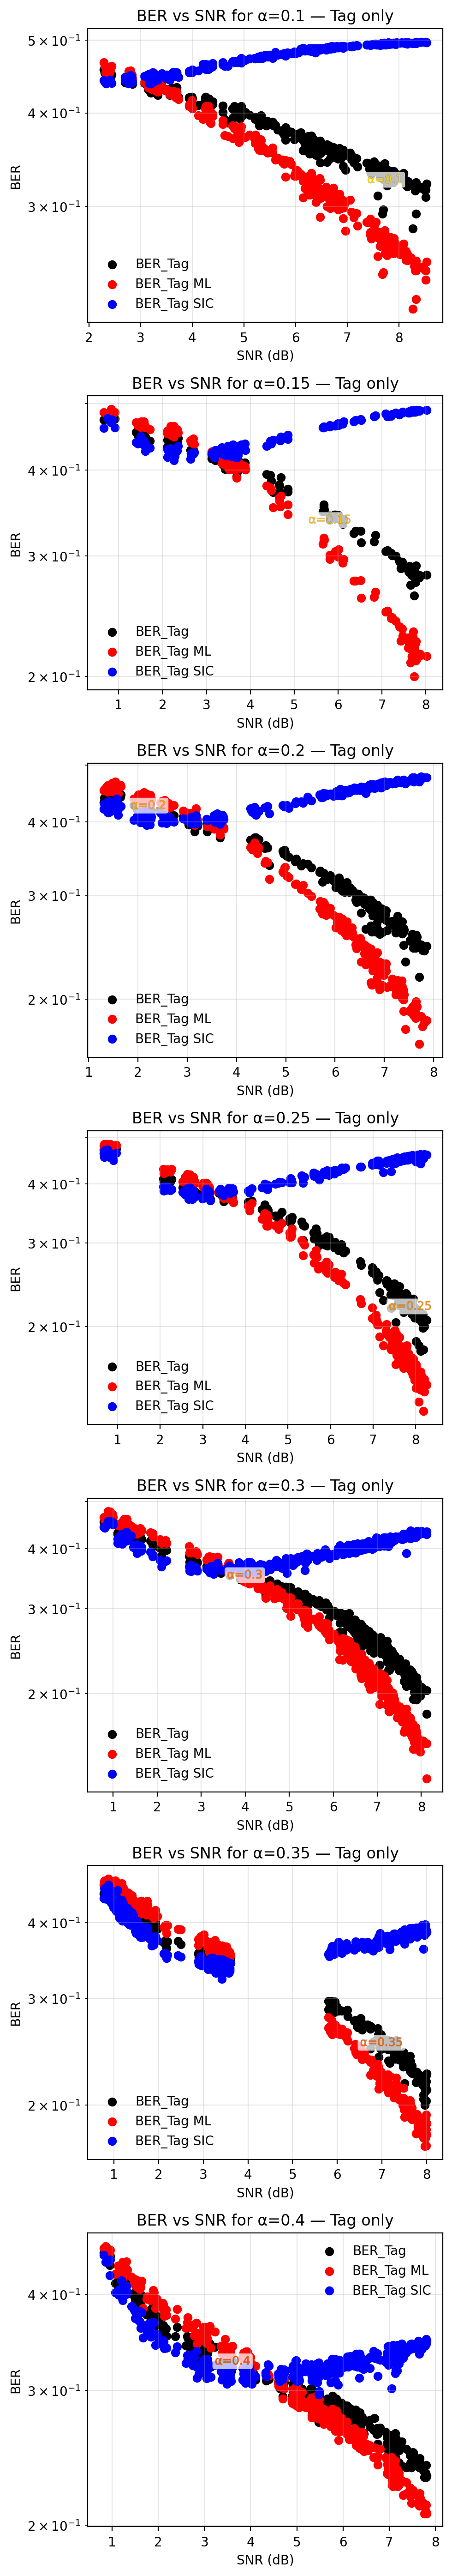

In [84]:
# plot the tag BER for ML and BER_tag
# plot_ber_vs_snr_by_alpha([dbs[0]], save_to="ber_vs_snr_alpha_on_line_ml.png")

# modifying the plot_BER_vs_snr_by_alpha function to show ML and SIC results for tag only and every alpha will be a dufferet subplot
def plot_ber_vs_snr_by_alpha(dfs, save_to=None, compare = True,
                             msg_cmap_name='summer', tag_cmap_name="autumn"):
    series = []
    for alpha, df in dfs.items():
        g = df.copy()
        if not g.empty:
            series.append((float(alpha), g))
    if not series:
        print("No data to plot.")
        return
    # sort so darker (low α) are drawn first, brighter on top
    series.sort(key=lambda x: x[0])
    alphas = [a for a, _ in series]
    a_min, a_max = min(alphas), max(alphas)
    if a_max == a_min:
        a_max = a_min + 1e-12
    norm = mpl.colors.Normalize(vmin=.05*a_min, vmax=1.4*a_max)
    tag_cmap = mpl.cm.get_cmap(tag_cmap_name)   
    fig, axs = plt.subplots(len(series), 1, figsize=(5, 4*len(series)), dpi=200)
    if len(series) == 1:
        axs = [axs]  # ensure axs is always a list
    for ax, (a, g) in zip(axs, series):
        # invert intensity so higher α => brighter
        shade = 1.0 - norm(a)
        tag_color = tag_cmap(shade)

        ax.scatter(g["SNR"], g["BER_tag"], 
                color='black', label="BER_Tag")

        # write α on each line (slightly different positions to reduce overlap)
        _text_on_curve(ax, g["SNR"], g["BER_tag"], f"α={a:g}", tag_color, frac=0.78)
        if compare:
            ax.scatter(g["SNR"], g["BER_tag_ml"], 
                    color='red', label="BER_Tag ML")
            ax.scatter(g["SNR"], g["BER_tag_sic"], 
                     color='blue', label="BER_Tag SIC")
        # styling
        ax.set_yscale("log")
        ax.set_xlabel("SNR (dB)")
        ax.set_ylabel("BER")
        ax.set_title(f"BER vs SNR for α={a:g} — Tag only")
        ax.grid(True, which="both", alpha=0.3)  
        # tiny legend just for type
        from matplotlib.lines import Line2D
        ax.legend( loc="best", frameon=False)
    fig.tight_layout()
    if save_to:
        fig.savefig(save_to, dpi=220, bbox_inches="tight")
    plt.show()  
# Usage:
plot_ber_vs_snr_by_alpha(dfs, save_to="ber_vs_snr_alpha_on_line_ml_sic.png", compare=True)